In [2]:
!pip install -q transformers torch scipy numpy matplotlib accelerate bitsandbytes sentencepiece einops

import torch
import torch.nn as nn
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
import scipy.linalg as la
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D視覚化用
import os
from typing import Dict, List, Tuple, Optional

# メモリ管理: CUDAメモリ拡張設定
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 感情データ: 各感情のテキストリストをDictで管理
EMOTION_DATA = {
    0: [  # Joy (喜び)
        "今日は最高の天気で、心が弾みます！とても楽しい一日になりそうです。",
        "友達と公園で楽しく遊び、笑いが止まりません！最高の時間です。",
        "新しい本が面白くて、ワクワクが止まりません！ページをめくる手が止まりません。",
        "夕食が美味しくて、幸せいっぱいです！家族と一緒に食べるのが一番です。",
        "散歩中に出会った花が美しくて、心が癒されます。自然の恵みに感謝！",
        "映画が感動的で、涙が止まりません。でもそれは喜びの涙です。",
        "音楽が心地よくて、踊りたくなります！リズムに合わせて体が動きます。",
        "お茶を飲む時間が穏やかで、至福の瞬間です。ゆっくり味わいます。",
        "手紙に温かい言葉を書けて、嬉しさがこみ上げます。相手の笑顔が想像できます。",
        "写真を撮るのが楽しくて、シャッターを切りまくりました！美しい瞬間を捉えました。"
    ],
    1: [  # Sad (悲しみ)
        "今日は天気が悪く、寂しい気持ちです。一人でいるのがつらいです。",
        "友達と公園に行きましたが、誰も来なくて悲しいです。期待が裏切られました。",
        "新しい本を買いましたが、内容が暗くて落ち込みます。読み進めるのが辛いです。",
        "夕食を作りましたが、味気なくて涙が出そうです。誰も褒めてくれません。",
        "散歩をしましたが、雨に降られて心が冷えます。家に帰りたくありません。",
        "映画を見ましたが、悲しい結末で胸が痛いです。忘れられません。",
        "音楽を聞きましたが、思い出が蘇って切なくなります。止めたくありません。",
        "お茶を飲みましたが、冷たくて孤独を感じます。一杯の温かさが欲しいです。",
        "手紙を書きましたが、返事が来ないかもと思うと不安です。",
        "写真を撮りましたが、笑顔が作れなくてぼやけています。"
    ],
    2: [  # Anger (怒り)
        "今日は天気が悪くて、腹が立ちます！こんな日に外出なんて最悪です。",
        "友達と公園に行きましたが、遅刻されてイライラします！信用できません。",
        "新しい本を買いましたが、高くて怒りが湧きます！騙された気分です。",
        "夕食を作りましたが、材料が足りなくて苛立ちます！計画が狂いました。",
        "散歩をしましたが、道にゴミが散らばって腹立たしいです。誰のせいですか！",
        "映画を見ましたが、くだらない展開でムカつきます。時間を無駄にしました。",
        "音楽を聞きましたが、うるさくて頭に来ます！静かにできませんか。",
        "お茶を飲みましたが、熱すぎて舌を火傷しそうで怒ります！注意してください。",
        "手紙を書きましたが、インクが切れてイライラします。こんな時に限って！",
        "写真を撮りましたが、ピントが合わず悔しいです。やり直しです。"
    ]
}

# 全テキストとラベルをリスト化
all_texts = [text for data in EMOTION_DATA.values() for text in data]
all_labels = [emo_id for emo_id, data in EMOTION_DATA.items() for _ in data]
EMO_NAMES = ["Joy (喜び)", "Sad (悲しみ)", "Anger (怒り)"]  # 感情名リスト

class EmotionSteering:
    """感情ステアリングのメインクラス: モデルロード、抽出、訓練、生成をまとめて管理"""

    def __init__(self, model_name: str = "rinna/japanese-gpt2-small", target_layer: int = -3):
        # 初期化: 変数を設定
        self.model_name = model_name
        self.target_layer = target_layer
        self.tokenizer = None
        self.model = None
        self.subspace = None
        self.centroids = None
        self.steering_mlps = None
        self.hidden_states = None
        self.labels = None
        self._hook_handle = None
        self._hook_data = {}
        self._load_model()  # モデルをロード

    def _load_model(self) -> None:
        """モデルとトークナイザーをfloat32でロードし、メモリ効率化"""
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            if self.tokenizer.pad_token is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token
            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_name, torch_dtype=torch.float32, low_cpu_mem_usage=True, device_map="auto"
            )
            self.model.gradient_checkpointing_enable()
            self.model.eval()
            print(f"モデルロード成功: 層数 {len(self.model.transformer.h)}")
        except Exception as e:
            raise RuntimeError(f"モデルロード失敗: {e}")

    def extract_hidden_states(self, texts: List[str], labels: List[int]) -> Tuple[np.ndarray, np.ndarray]:
        """テキストから隠れ状態を抽出 (float32で統一)"""
        hidden_states_list = []
        for text in texts:
            inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
            with torch.no_grad():
                hs = self.model(**inputs, output_hidden_states=True).hidden_states[self.target_layer][0, -1].cpu().numpy().astype(np.float32)
            hidden_states_list.append(hs)
        return np.array(hidden_states_list), np.array(labels)

    def extract_emotion_subspace(self, hidden_states: np.ndarray, k: int = 3) -> np.ndarray:
        """隠れ状態から感情サブスペースをSVDで抽出"""
        centered = hidden_states - hidden_states.mean(axis=0)
        U, Sigma, Vt = la.svd(centered, full_matrices=False)
        return Vt[:k].T.astype(np.float32)

    def compute_emotion_centroids(self, hidden_states: np.ndarray, labels: np.ndarray, subspace: np.ndarray) -> Dict[int, np.ndarray]:
        """各感情の中心点を計算"""
        centroids = {}
        for emo in np.unique(labels):
            mask = labels == emo
            projs = hidden_states[mask] @ subspace
            centroids[emo] = projs.mean(axis=0).astype(np.float32)
        return centroids

    def train_steering_modules(self, hidden_states: np.ndarray, labels: np.ndarray, centroids: Dict[int, np.ndarray], k: int = 3,
                               epochs: int = 200, lr: float = 0.005) -> Dict[int, nn.Module]:
        """ステアリング用のMLPを訓練 (NaN回避で勾配クリップ)"""
        class SteeringMLP(nn.Module):
            def __init__(self, input_dim: int, hidden_dim: int = 64):
                super().__init__()
                self.fc1 = nn.Linear(input_dim, hidden_dim)
                self.fc2 = nn.Linear(hidden_dim, input_dim)
                self.gelu = nn.GELU()

            def forward(self, x: torch.Tensor) -> torch.Tensor:
                return self.fc2(self.gelu(self.fc1(x)))

        mlps = {}
        subspace = self.subspace
        for emo in np.unique(labels):
            mask = labels == emo
            projs = hidden_states[mask] @ subspace
            target = np.tile(centroids[emo], (len(projs), 1))
            deltas = target - projs
            projs_t = torch.tensor(projs, dtype=torch.float32).to(device)
            deltas_t = torch.tensor(deltas, dtype=torch.float32).to(device)

            mlp = SteeringMLP(k).to(device)
            optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)
            criterion = nn.MSELoss()
            mlp.train()

            for epoch in range(epochs):
                pred = mlp(projs_t)
                loss = criterion(pred, deltas_t)
                torch.nn.utils.clip_grad_norm_(mlp.parameters(), max_norm=0.5)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if np.isnan(loss.item()) or np.isinf(loss.item()):
                    print(f"NaN/Inf検出 (感情{emo}, epoch{epoch}): lrを減らす")
                    for pg in optimizer.param_groups: pg['lr'] *= 0.1
                if epoch % 50 == 0:
                    print(f"感情{emo}, epoch{epoch}, loss: {loss.item():.4f}")

            mlp.eval()
            mlps[emo] = mlp
        return mlps

    def _steering_hook(self, module: nn.Module, input: Tuple[torch.Tensor], output: Tuple[torch.Tensor]) -> Tuple[torch.Tensor]:
        """生成中に隠れ状態を感情方向に調整 (フック関数)"""
        hs = output[0]
        current_hs = hs[0, -1].clone()
        subspace_t = self._hook_data.get('subspace_t')
        mlp = self._hook_data.get('mlp')
        alpha = self._hook_data.get('alpha', 1.0)
        if subspace_t is None or mlp is None:
            return output
        proj = torch.matmul(current_hs, subspace_t)
        shift = mlp(proj.unsqueeze(0)).squeeze(0)
        delta = torch.matmul(subspace_t, shift.unsqueeze(1)).squeeze() * alpha
        hs[0, -1] += delta
        return (hs,) + output[1:]

    def generate_with_emotion(self, prompt: str, emotion_id: int, alpha: float = 1.2, temperature: float = 0.8,
                              max_new_tokens: int = 100) -> str:
        """指定感情でテキスト生成 (フックでステアリング)"""
        if self.steering_mlps is None:
            raise ValueError("まず訓練を実行してください")
        subspace_t = torch.tensor(self.subspace, dtype=torch.float32).to(device)
        mlp = self.steering_mlps[emotion_id].to(device)
        eos_id = self.tokenizer.eos_token_id or self.tokenizer.pad_token_id

        # 介入レイヤー特定
        layers = self.model.transformer.h
        num_layers = len(layers)
        layer_idx = num_layers + self.target_layer if self.target_layer < 0 else self.target_layer
        if not (0 <= layer_idx < num_layers):
            raise ValueError(f"無効なレイヤー: {self.target_layer}")
        layer = layers[layer_idx]

        # フック登録
        self._hook_data = {'subspace_t': subspace_t, 'mlp': mlp, 'alpha': alpha}
        self._hook_handle = layer.register_forward_hook(self._steering_hook)

        try:
            inputs = self.tokenizer(prompt, return_tensors="pt").to(device)
            generated = self.model.generate(
                **inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True,
                pad_token_id=eos_id, use_cache=True, output_hidden_states=False
            )
            return self.tokenizer.decode(generated[0], skip_special_tokens=True)
        except Exception as e:
            print(f"生成エラー ({e}): 通常生成にフォールバック")
            return self._generate_fallback(prompt, temperature, max_new_tokens, eos_id)
        finally:
            if self._hook_handle:
                self._hook_handle.remove()
                self._hook_handle = None
            self._hook_data = {}

    def _generate_fallback(self, prompt: str, temperature: float, max_new_tokens: int, eos_id: int) -> str:
        """フックなしの通常生成 (エラー時用)"""
        inputs = self.tokenizer(prompt, return_tensors="pt").to(device)
        generated = inputs['input_ids'].clone()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                logits = self.model(generated).logits[0, -1]
                probs = torch.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                generated = torch.cat([generated, next_token.unsqueeze(0)], dim=-1)
                if next_token.item() == eos_id:
                    break
        return self.tokenizer.decode(generated[0], skip_special_tokens=True)

    def fit(self, texts: List[str], labels: List[int]) -> None:
        """全体訓練: 隠れ状態抽出 → サブスペース → 中心計算 → MLP訓練"""
        print("隠れ状態抽出...")
        self.hidden_states, self.labels = self.extract_hidden_states(texts, labels)
        print(f"形状: {self.hidden_states.shape}")
        print("サブスペース抽出...")
        self.subspace = self.extract_emotion_subspace(self.hidden_states)
        print(f"サブスペース形状: {self.subspace.shape}")
        print("中心計算...")
        self.centroids = self.compute_emotion_centroids(self.hidden_states, self.labels, self.subspace)
        print("ステアリング訓練...")
        self.steering_mlps = self.train_steering_modules(self.hidden_states, self.labels, self.centroids)
        print("訓練完了")

    def _project_to_emotion_space(self, texts: List[str]) -> np.ndarray:
        """テキストを感情空間に射影"""
        hs_list = []
        with torch.no_grad():
            for text in texts:
                inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
                hs = self.model(**inputs, output_hidden_states=True).hidden_states[self.target_layer][0, -1].cpu().numpy().astype(np.float32)
                hs_list.append(hs)
        return np.array(hs_list) @ self.subspace

    def visualize(self, dim: int = 2, neutral_prompt: Optional[str] = None, generated_texts: Optional[List[str]] = None) -> None:
        """感情空間を2D/3Dで視覚化 (共通ヘルパー)"""
        if dim not in (2, 3):
            raise ValueError("dimは2または3のみ")
        projs = self.hidden_states @ self.subspace
        colors = ['orange', 'blue', 'red']
        labels_unique = np.unique(self.labels)
        fig = plt.figure(figsize=(9 if dim == 2 else 10, 7 if dim == 2 else 8))
        ax = fig.subplots() if dim == 2 else fig.add_subplot(111, projection='3d')

        for i, name in enumerate(EMO_NAMES):
            mask = self.labels == labels_unique[i]
            if dim == 2:
                ax.scatter(projs[mask, 0], projs[mask, 1], c=colors[i], label=f"Data: {name}", alpha=0.3)
                ax.scatter(self.centroids[i][0], self.centroids[i][1], c=colors[i], s=250, marker='X', ec='black', label=f"Centroid: {name}")
            else:
                ax.scatter(projs[mask, 0], projs[mask, 1], projs[mask, 2], c=colors[i], label=f"Data: {name}", alpha=0.1)
                ax.scatter(self.centroids[i][0], self.centroids[i][1], self.centroids[i][2], c=colors[i], s=250, marker='X', ec='black', label=f"Centroid: {name}")

        if neutral_prompt:
            neu_proj = self._project_to_emotion_space([neutral_prompt])[0]
            if dim == 2:
                ax.scatter(neu_proj[0], neu_proj[1], c='green', s=180, marker='P', label="Neutral")
            else:
                ax.scatter(neu_proj[0], neu_proj[1], neu_proj[2], c='green', s=180, marker='P', label="Neutral")

        if generated_texts:
            gen_projs = self._project_to_emotion_space(generated_texts)
            for i, name in enumerate(EMO_NAMES):
                if dim == 2:
                    ax.scatter(gen_projs[i, 0], gen_projs[i, 1], c=colors[i], marker='D', s=120, label=f"Generated: {name}")
                else:
                    ax.scatter(gen_projs[i, 0], gen_projs[i, 1], gen_projs[i, 2], c=colors[i], marker='D', s=120, label=f"Generated: {name}")

        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        if dim == 3:
            ax.set_zlabel("Dim 3")
            ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
            plt.tight_layout()
        else:
            ax.legend()
            ax.grid(True)
        ax.set_title(f"{dim}D Emotion Space (Layer {self.target_layer})")
        plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 13.2 MB/s eta 0:00:00
Using device: cuda


対象レイヤー: -3
モデルロード成功: 層数 12
隠れ状態抽出...
形状: (30, 768)
サブスペース抽出...
サブスペース形状: (768, 3)
中心計算...
ステアリング訓練...
感情0, epoch0, loss: 225.6938
感情0, epoch50, loss: 53.6700
感情0, epoch100, loss: 49.3503
感情0, epoch150, loss: 44.0254
感情1, epoch0, loss: 710.9178
感情1, epoch50, loss: 86.7456
感情1, epoch100, loss: 62.8774
感情1, epoch150, loss: 44.8643
感情2, epoch0, loss: 248.4508
感情2, epoch50, loss: 30.1771
感情2, epoch100, loss: 25.1610
感情2, epoch150, loss: 23.6115
訓練完了
Joy (喜び): 朝起きると寒い。朝食後、テレビをつけると、天気予報に「冷えます」の文字があった。 今日は、久しぶりにテレビをつけた。 天気予報は、とても暑い。 テレビをつけると、天気が良くなっている。 1時間前の天気予報が、とても寒かった。 テレビをつけると、全国で大雨警報。 テレビをつけると、東北地方は、大雨警報。 テレビをつけると、関東以北は、大雨警報。 全国で、大雨警報
Sad (悲しみ): 朝起きると寒い。雨も降ってきた。 朝6時前に起きて、洗濯物を取り込む。 買い物に出かける。 朝食を食べる。 朝6時過ぎに起きて、洗濯物を洗い出す。 雨が降ってきた。 雨は少しづつ、上がってきている。 買い物に出かける。 朝6時過ぎに起きて、洗濯物を洗い出す。 雨が強かった。 朝6時過ぎに起きて、洗濯物を洗い出す。 雨
Anger (怒り): 朝起きると寒い。朝ご飯も食べずに、部屋でただおとなしくしてたら、 昨日に引き続き急に寒くなった。 でもやっぱり寒い。 でも、やっぱり暖かいのはありがたい。 今日は、早起きして洗濯機でお手入れをした。 洗濯機は、大体1時間に2回、お手洗いもお手入れも1回で済みます。 洗濯機1回だと、2〜3分で乾
2D視覚化...


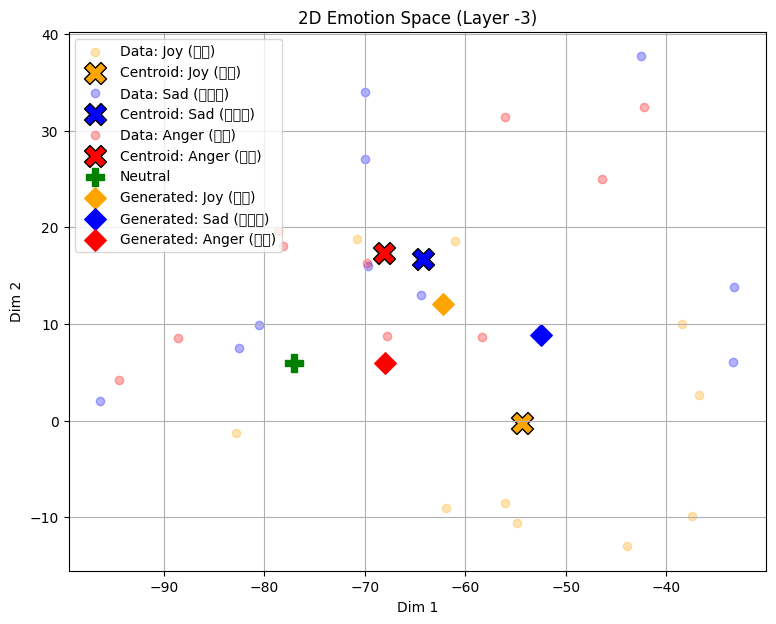

3D視覚化...


/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 21916 (\N{CJK UNIFIED IDEOGRAPH-559C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 12403 (\N{HIRAGANA LETTER BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 24754 (\N{CJK UNIFIED IDEOGRAPH-60B2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 12415 (\N{HIRAGANA LETTER MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 24594 (\N{CJK UNIFIED IDEOGRAPH-6012}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-192247386.py:301: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  p

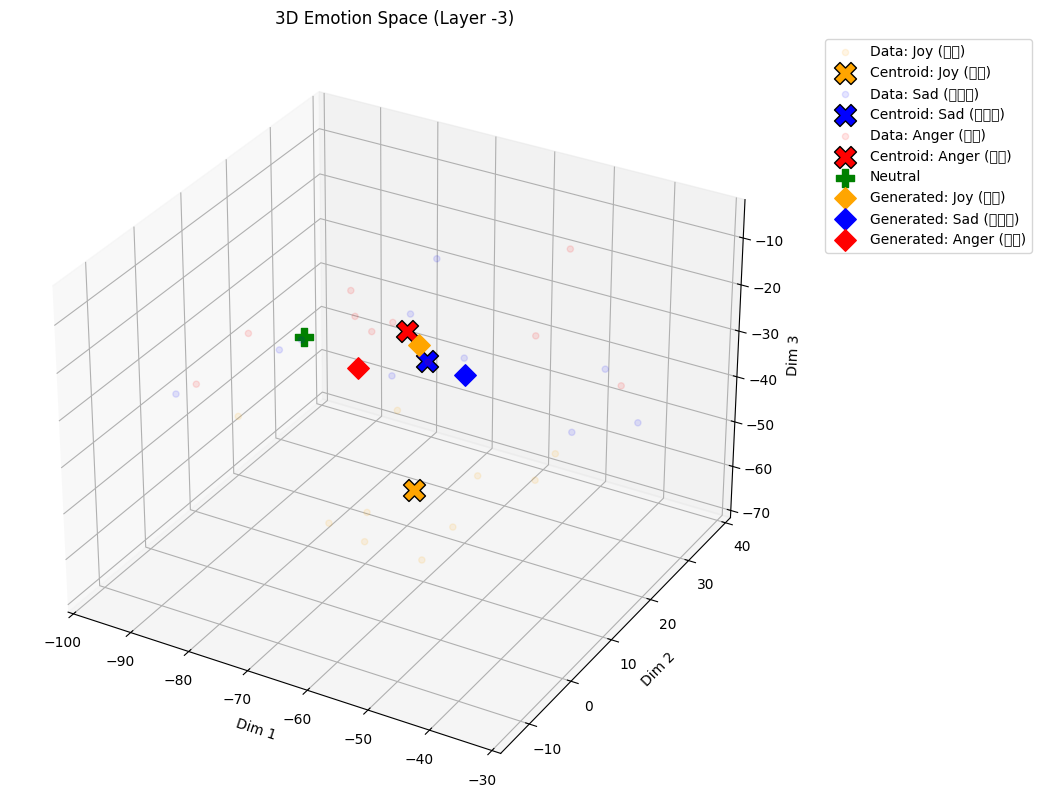

In [4]:
# --- メイン実行 ---
TARGET_LAYER = -3
print(f"対象レイヤー: {TARGET_LAYER}")

steering = EmotionSteering(target_layer=TARGET_LAYER)
steering.fit(all_texts, all_labels)

# 生成例
neutral_prompt = "朝起きると寒い。"
generated_texts = []
for emo_id, name in enumerate(EMO_NAMES):
    gen_text = steering.generate_with_emotion(neutral_prompt, emo_id, alpha=1.2, max_new_tokens=100)
    print(f"{name}: {gen_text}")
    generated_texts.append(gen_text)

# 視覚化
print("2D視覚化...")
steering.visualize(dim=2, neutral_prompt=neutral_prompt, generated_texts=generated_texts)

print("3D視覚化...")
steering.visualize(dim=3, neutral_prompt=neutral_prompt, generated_texts=generated_texts)

## 記事解説用

In [ ]:
import torch; import torch.nn as nn; import numpy as np; (以降省略)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_DATA = {　# 感情データ: 各感情のテキストリストをDictで管理
    0: [ "今日は最高の天気で、心が弾みます！とても楽しい一日になりそうです。",
        (中略)
    1: [ "今日は天気が悪く、寂しい気持ちです。一人でいるのがつらいです。",
        (中略)
    2: [ "今日は天気が悪くて、腹が立ちます！こんな日に外出なんて最悪です。",
        (中略)
all_texts = [text for data in EMOTION_DATA.values() for text in data]　# 全テキストとラベルをリスト化
all_labels = [emo_id for emo_id, data in EMOTION_DATA.items() for _ in data]
EMO_NAMES = ["Joy (喜び)", "Sad (悲しみ)", "Anger (怒り)"]               # 感情名リスト

class EmotionSteering:
    def __init__(self, model_name: str = "rinna/japanese-gpt2-small", target_layer: int = -3):
        （中略）
        self._load_model()  # モデルをロード
    def _load_model(self) -> None:
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            (中略)
            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_name, torch_dtype=torch.float32, low_cpu_mem_usage=True, device_map="auto")
            self.model.gradient_checkpointing_enable(); self.model.eval()
        except Exception as e:
            raise RuntimeError(f"モデルロード失敗: {e}")
    def extract_hidden_states(self, texts: List[str], labels: List[int]) -> Tuple[np.ndarray, np.ndarray]:
        hidden_states_list = []
        for text in texts:
            inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
            with torch.no_grad():
                hs = self.model(**inputs, output_hidden_states=True).hidden_states[self.target_layer]\
                    [0, -1].cpu().numpy().astype(np.float32)
            hidden_states_list.append(hs)
        return np.array(hidden_states_list), np.array(labels)
    def extract_emotion_subspace(self, hidden_states: np.ndarray, k: int = 3) -> np.ndarray:
        centered = hidden_states - hidden_states.mean(axis=0)
        U, Sigma, Vt = la.svd(centered, full_matrices=False)
        return Vt[:k].T.astype(np.float32)
    def compute_emotion_centroids(self, hidden_states: np.ndarray, labels: np.ndarray, 
                                  subspace: np.ndarray) -> Dict[int, np.ndarray]:
        (中略)
        return centroids
    def train_steering_modules(self, hidden_states: np.ndarray, labels: np.ndarray,
                               centroids: Dict[int, np.ndarray], k: int = 3,
                               epochs: int = 200, lr: float = 0.005) -> Dict[int, nn.Module]:
        class SteeringMLP(nn.Module):
            def __init__(self, input_dim: int, hidden_dim: int = 64):
                super().__init__()
                self.fc1 = nn.Linear(input_dim, hidden_dim); self.fc2 = nn.Linear(hidden_dim, input_dim)
                self.gelu = nn.GELU()
            def forward(self, x: torch.Tensor) -> torch.Tensor:
                return self.fc2(self.gelu(self.fc1(x)))
        mlps = {}; subspace = self.subspace
        for emo in np.unique(labels):
            (中略)
            mlp = SteeringMLP(k).to(device)
            (中略)
            mlp.train()
            for epoch in range(epochs):
                (中略)
            mlp.eval(); mlps[emo] = mlp
        return mlps
    def _steering_hook(self, module: nn.Module, input: Tuple[torch.Tensor], 
                       output: Tuple[torch.Tensor]) -> Tuple[torch.Tensor]:
        (中略)
        return (hs,) + output[1:]
    def generate_with_emotion(self, prompt: str, emotion_id: int, alpha: float = 1.2, 
                              temperature: float = 0.8, max_new_tokens: int = 100) -> str:
        subspace_t = torch.tensor(self.subspace, dtype=torch.float32).to(device)
        mlp = self.steering_mlps[emotion_id].to(device)
        eos_id = self.tokenizer.eos_token_id or self.tokenizer.pad_token_id
        layers = self.model.transformer.h; num_layers = len(layers)
        layer_idx = num_layers + self.target_layer if self.target_layer < 0 else self.target_layer
        layer = layers[layer_idx]
        self._hook_data = {'subspace_t': subspace_t, 'mlp': mlp, 'alpha': alpha}　# フック登録
        self._hook_handle = layer.register_forward_hook(self._steering_hook)
        try:
            inputs = self.tokenizer(prompt, return_tensors="pt").to(device)
            generated = self.model.generate(
                **inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True,
                pad_token_id=eos_id, use_cache=True, output_hidden_states=False)
            return self.tokenizer.decode(generated[0], skip_special_tokens=True)
        except Exception as e:
            return self._generate_fallback(prompt, temperature, max_new_tokens, eos_id)
        finally:
            if self._hook_handle:
                self._hook_handle.remove(); self._hook_handle = None
            self._hook_data = {}
    def _generate_fallback(self, prompt: str, temperature: float, max_new_tokens: int, eos_id: int) -> str:
        inputs = self.tokenizer(prompt, return_tensors="pt").to(device)
        generated = inputs['input_ids'].clone()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                logits = self.model(generated).logits[0, -1]
                probs = torch.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                generated = torch.cat([generated, next_token.unsqueeze(0)], dim=-1)
                if next_token.item() == eos_id:
                    break
        return self.tokenizer.decode(generated[0], skip_special_tokens=True)
    def fit(self, texts: List[str], labels: List[int]) -> None:
        self.hidden_states, self.labels = self.extract_hidden_states(texts, labels)
        self.subspace = self.extract_emotion_subspace(self.hidden_states)
        self.centroids = self.compute_emotion_centroids(self.hidden_states, self.labels, self.subspace)
        self.steering_mlps = self.train_steering_modules(self.hidden_states, self.labels, self.centroids)
    def _project_to_emotion_space(self, texts: List[str]) -> np.ndarray:
        (中略)
        return np.array(hs_list) @ self.subspace
    def visualize(self, dim: int = 2, neutral_prompt: Optional[str] = None, 
                  generated_texts: Optional[List[str]] = None) -> None:
        (省略)

TARGET_LAYER = -3
steering = EmotionSteering(target_layer=TARGET_LAYER); steering.fit(all_texts, all_labels)
neutral_prompt = "朝起きると寒い。"; generated_texts = []
for emo_id, name in enumerate(EMO_NAMES):
    gen_text = steering.generate_with_emotion(neutral_prompt, emo_id, alpha=1.2, max_new_tokens=100)
    print(f"{name}: {gen_text}")
    generated_texts.append(gen_text)
steering.visualize(dim=2, neutral_prompt=neutral_prompt, generated_texts=generated_texts) # 可視化